<a href="https://colab.research.google.com/github/Caosbot/Treinos_Python/blob/Machine_Learning/CNN%2BYolo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prev com Yolo

In [ ]:
from ultralytics import YOLO
import os
from random import randint
import cv2
import matplotlib.pyplot as plt
import torch
import numpy as np

In [ ]:
def mostrar(imagem,title):
  fig = plt.gcf()
  fig.set_size_inches(20,10)
  plt.imshow(imagem, cmap='gray')
  plt.title(title)
  #plt.axis('off')
  plt.show()

## Caminhos

In [ ]:
#Caminho da pasta inicial
path= 'C:/Malaria'

In [ ]:
path_dataset = path+'/Tudo/dataset'
path_dataset

'C:/Malaria/Tudo/dataset'

In [ ]:
path_image_test = path_dataset+'/test/images'
path_image_test

'C:/Malaria/Tudo/dataset/test/images'

## Exemplo

In [ ]:
best = r'C:\Malaria\runs\detect\All_Data\weights\best.pt'

In [ ]:
caminhos_pasta = [os.path.join(path_image_test, f) for f in os.listdir(path_image_test)]
nums_pasta = randint(0, len(caminhos_pasta) - 1)
print(f'Numero aleatorio: {nums_pasta}, Qtd: {len(caminhos_pasta)}')
pasta = caminhos_pasta[nums_pasta]
print(f'Nome: {pasta}')

Numero aleatorio: 44, Qtd: 62
Nome: C:/Malaria/Tudo/dataset/test/images\TF112_CJ10


In [ ]:
caminhos_arquivo = [os.path.join(pasta, f) for f in os.listdir(pasta)]
nums_arquivo = randint(0, len(caminhos_arquivo) - 1)
print(f'Numero aleatorio: {nums_arquivo}, Qtd: {len(caminhos_arquivo)}')
arquivo = caminhos_arquivo[nums_arquivo]
print(f'Nome: {arquivo}')

Numeros aleatorio: 3, Qtd: 15
Nome: C:/Malaria/Tudo/dataset/test/images\TF112_CJ10\20170830_202539.jpg


In [ ]:
image_teste = cv2.imread(arquivo)
image_bound = image_teste.copy()

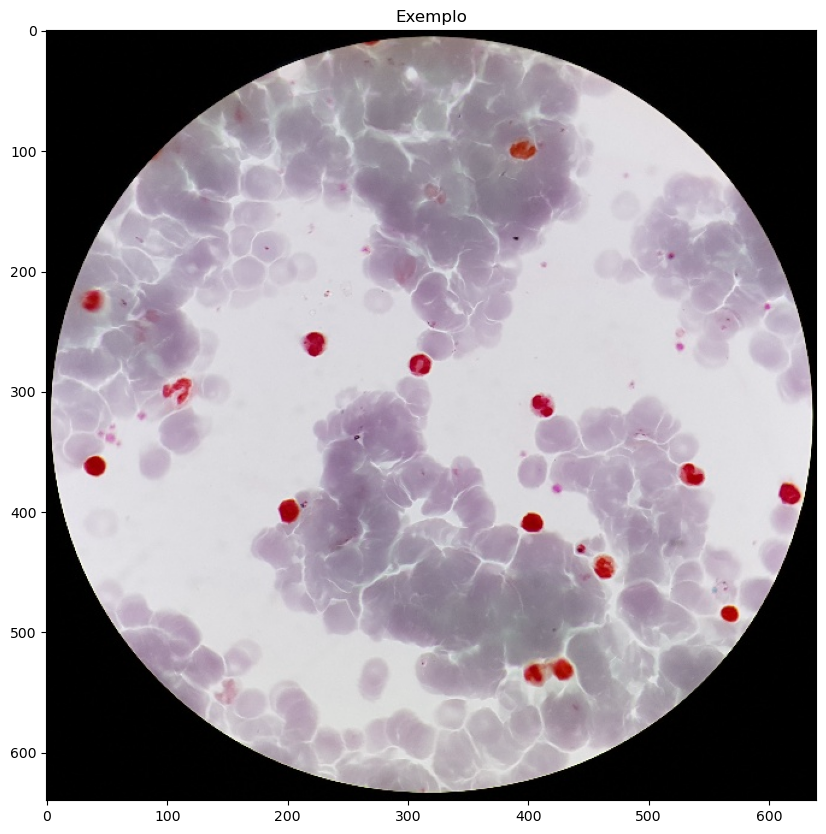

In [ ]:
mostrar(image_teste,'Exemplo')

## Corte

In [ ]:
# Define cores para cada tipo de célula
cores = {
    "white_cell": (255, 0, 0),  # Vermelho
    "malaria": (0, 255, 0),  # Verde
}

# Define a espessura da linha
espessura_linha = 1

In [ ]:
# Define as listas de células e suas quantidades
white_cell=[]
malaria =[]
cell_types = ["white_cell","malaria"]
cell_counts = []
count=0

# Carrega o modelo e executa a inferência
model1 = YOLO(best)  # pretrained YOLOv8n model
results1 = model1([image_teste])  # Guarda em result1 objects Comando tirado(, imgsz=640)
##########################################
boxes = results1[0].boxes.xywh.tolist()
##########################################
# Processa os resultados
boxes_filtered = [box for result in results1 for box in result.boxes if int(box.cls[0].item()) != 3]

for box in boxes_filtered:
  if int(box.cls[0].item()) == 0:
    white_cell.append(box[0].xyxy[0].tolist())
  elif int(box.cls[0].item()) == 1:
     malaria.append(box[0].xyxy[0].tolist())
  # elif int(box.cls[0].item()) == 2:
  #   leucocito.append(box[0].xyxy[0].tolist())
  # elif int(box.cls[0].item()) == 4:
  #   ring.append(box[0].xyxy[0].tolist())
  # elif int(box.cls[0].item()) == 5:
  #   schizont.append(box[0].xyxy[0].tolist())
  # elif int(box.cls[0].item()) == 6:
  #   trophozoite.append(box[0].xyxy[0].tolist())

# Preenche a lista de quantidades
for cell_type in cell_types:
  # Verifica se a variável associada ao tipo de célula existe
  if locals()[cell_type]:  # Acessa variáveis dinamicamente
    cell_counts.append(len(locals()[cell_type]))
  else:
    cell_counts.append(0)  # Quantidade zero se a lista estiver vazia

# Combina tipos de células e quantidades em uma lista
cell_data = list(zip(cell_types, cell_counts))

# Exibe os resultados
total = 0
for cell_type, count in cell_data:
  total+=count
  print(f"Quantidade de {cell_type}: {count}")

  # print(f"Conteúdo de {cell_type}:")
  # for item in locals()[cell_type]:
  #   print(item)
print(f'Total: {total}')


0: 640x640 16 white_cells, 11 malarias, 60.6ms
Speed: 9.0ms preprocess, 60.6ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)
Quantidade de white_cell: 16
Quantidade de malaria: 11
Total: 27


nt_white_cell: 11 | nt_malaria: 16


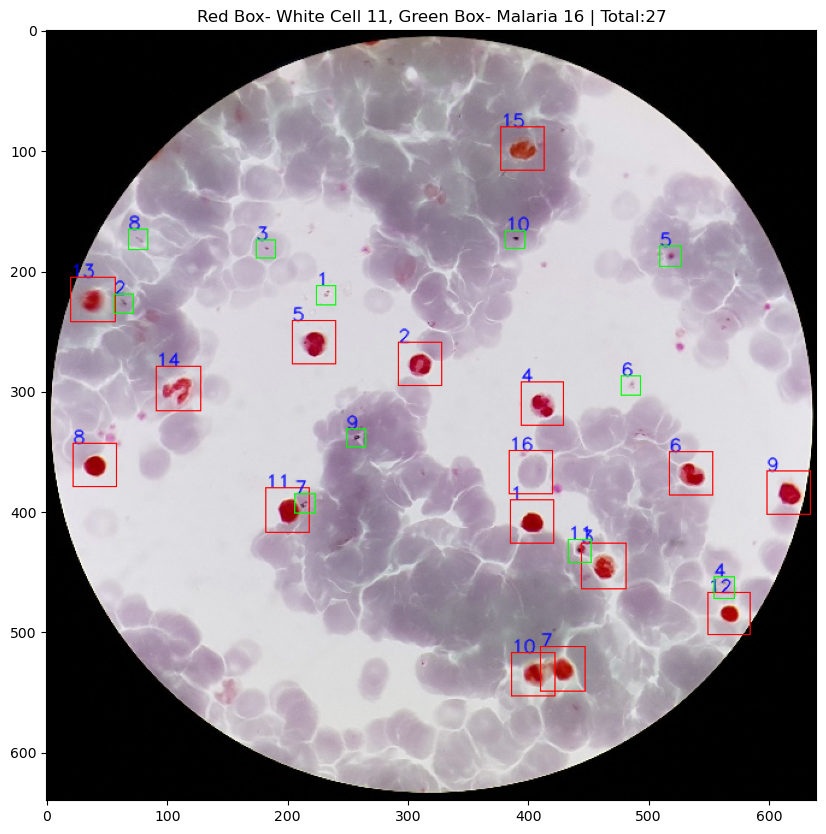

In [ ]:
image_teste = cv2.imread(arquivo)
image_bound = image_teste.copy()
images_yolo=[]
qtd=0
nt_malaria=0
nt_white_cell=0
# Loop para recortar e plotar células individualmente
for cell_type, count in cell_data:
  if count > 0:  # Processa apenas células com detecções

    # Cria uma subpasta para cada tipo de célula
    #os.makedirs(f"{crop_data_path}/{cell_type}", exist_ok=True)  # Cria pasta se não existir
    for i, box in enumerate(locals()[cell_type]):
      qtd+=1

      x1, y1, x2, y2 = box
      # # Recorta o objeto usando as coordenadas da caixa delimitadora
      crop_object = image_teste[int(y1):int(y2), int(x1):int(x2)]

      # # Redimensionamento da imagem recortada
      crop_object = cv2.resize(crop_object, dsize=(50, 50))
      # Salva o objeto recortado
      #cv2.imwrite(f"{crop_data_path}/{cell_type}/{cell_type}{i + 1}.jpg", ultralytics_crop_object)
      images_yolo.append(np.array(crop_object))

      # Converte a caixa para valores inteiros
      x1, y1, x2, y2 = int(box[0]), int(box[1]), int(box[2]), int(box[3])

      if cell_type=='malaria':
        nt_white_cell+=1
        cv2.putText(image_bound, str(nt_white_cell), (x1, y1), 0, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
      else:
        nt_malaria+=1
        cv2.putText(image_bound, str(nt_malaria), (x1, y1), 0, 0.5, (0, 0, 255), 1, cv2.LINE_AA)


      # Desenha a bounding box na imagem original
      cv2.rectangle(image_bound, (x1, y1), (x2, y2), cores[cell_type], espessura_linha)


      # Desenha o círculo na imagem original
      # centro = (int((x1+x2)//2),int((y1+y2)//2))
      # l = x2 - x1
      # raio = (l + y2 - y1) // 4
      # #cv2.circle(manipulado, centro, raio, cor_circulo, thickness=2)

      # # Plota o objeto recortado
      #plt.figure(figsize=(8, 6))  # Define o tamanho da figura (opcional)
      #plt.imshow(ultralytics_crop_object)
      #plt.title(f"Célula {cell_type} {i + 1}")  # Adiciona título
      #plt.axis('off')  # Desliga rótulos e marcas do eixo
      #plt.show()  # Exibe o gráfico
print(f'nt_white_cell: {nt_white_cell} | nt_malaria: {nt_malaria}')
mostrar(image_bound, f"Red Box- White Cell {nt_white_cell}, Green Box- Malaria {nt_malaria} | Total:{qtd}")

#cv2.imwrite(f"{crop_data_path}/{cell_type}/bounding.jpg", manipulado)

# CNN

## Bibliotecas iniciais

In [ ]:
# Importar alguns dos módulos necessários
import os
#import zipfile
import cv2
from PIL import Image

import math
import matplotlib.pyplot as plt
from datetime import datetime
import random
import time

In [ ]:
# Obter data e hora atuais
data_hora_atual = datetime.now()

# Formatar a data e hora
print(data_hora_atual.strftime("%H:%M:%S %d-%m-%Y"))

04:42:51 17-06-2024


## Dataset

In [ ]:
#main = r'F:\Dataset\CNN'
main = r'F:\Dataset\Crop'
#vivax_path_train = r'F:\Dataset\CNN\Vivax\Train'
vivax_path = main+'\Vivax'
#vivax_path_valid = r'F:\Dataset\CNN\Vivax\Valid'

#vivax_path_test = r'F:\Dataset\CNN\Vivax\Test'

#falciparum_path = r'F:\Dataset\CNN\Falciparum'
falciparum_path = main+'\Falciparum'
#white_path = r'F:\Dataset\CNN\WhiteBloodCells'
white_path = main+'\WhiteBloodCells'

In [ ]:
#vivax_names_train = [os.path.join(vivax_path_train,f) for f in os.listdir(vivax_path_train)]
#vivax_names_valid = [os.path.join(vivax_path_valid,f) for f in os.listdir(vivax_path_valid)]
#vivax_names_test = [os.path.join(vivax_path_test,f) for f in os.listdir(vivax_path_test)]
#vivax_names = vivax_names_train+vivax_names_valid+vivax_names_test
vivax_names = [os.path.join(vivax_path,f) for f in os.listdir(vivax_path)]
falciparum_names = [os.path.join(falciparum_path,f) for f in os.listdir(falciparum_path)]
white_names = [os.path.join(white_path,f) for f in os.listdir(white_path)]

In [ ]:
#vivax_train_qtd =  len(vivax_names_train)
#vivax_valid_qtd =  len(vivax_names_valid)
#vivax_test_qtd =  len(vivax_names_test)
vivax_qtd =  len(vivax_names)
falciparum_qtd = len(falciparum_names)
white_qtd = len(white_names)
#vivax_total = vivax_train_qtd+vivax_valid_qtd+vivax_test_qtd
print(f'vivax_qtd: {vivax_qtd}\nfalciparum_qtd: {falciparum_qtd}\nwhite_names: {white_qtd}')

vivax_qtd: 25706
falciparum_qtd: 84509
white_names: 35449


In [ ]:
def Dividir_data (valor_total):
  para_treino = 70
  para_teste = 20
  para_validacao = 10

  para_treinor = math.floor(valor_total * (para_treino / 100))
  para_tester = math.floor(valor_total * (para_teste / 100))
  para_validacaor = math.floor(valor_total * (para_validacao / 100))

  #para_treinor = valor_total * (para_treino / 100) - para_treinor
  #para_tester = valor_total * (para_teste / 100) - para_tester
  #para_validacaor = valor_total * (para_validacao / 100) - para_validacaor

  print(f"{para_treino}% de {valor_total} é {para_treinor:.0f}")
  print(f"{para_teste}% de {valor_total} é {para_tester:.0f}")
  print(f"{para_validacao}% de {valor_total} é {para_validacaor:.0f}")

In [ ]:
print ('Vivax')
Dividir_data(vivax_qtd)
print ('\nFalciparum')
Dividir_data(falciparum_qtd)
print ('\nWhiteCell')
Dividir_data(white_qtd)

Vivax
70% de 25706 é 17994
20% de 25706 é 5141
10% de 25706 é 2570

Falciparum
70% de 84509 é 59156
20% de 84509 é 16901
10% de 84509 é 8450

WhiteCell
70% de 35449 é 24814
20% de 35449 é 7089
10% de 35449 é 3544


In [ ]:
tamanho = 10000
falciparum_names_train = random.sample(falciparum_names, tamanho)
vivax_names_train = random.sample(vivax_names, tamanho)
white_names_train = random.sample(white_names, tamanho)
#falciparum_names_train = falciparum_names[:17994]
#vivax_names_train = vivax_names[:17994]
#white_names_train = white_names[:17994]
print(tamanho*3)

30000


In [ ]:
def mostrar(imagem,title):
  fig = plt.gcf()
  fig.set_size_inches(20,10)
  plt.imshow(imagem, cmap='gray')
  plt.title(title)
  #plt.axis('off')
  plt.show()

In [ ]:
r =np.random.randint(0,len(vivax_names_train))
r

3352

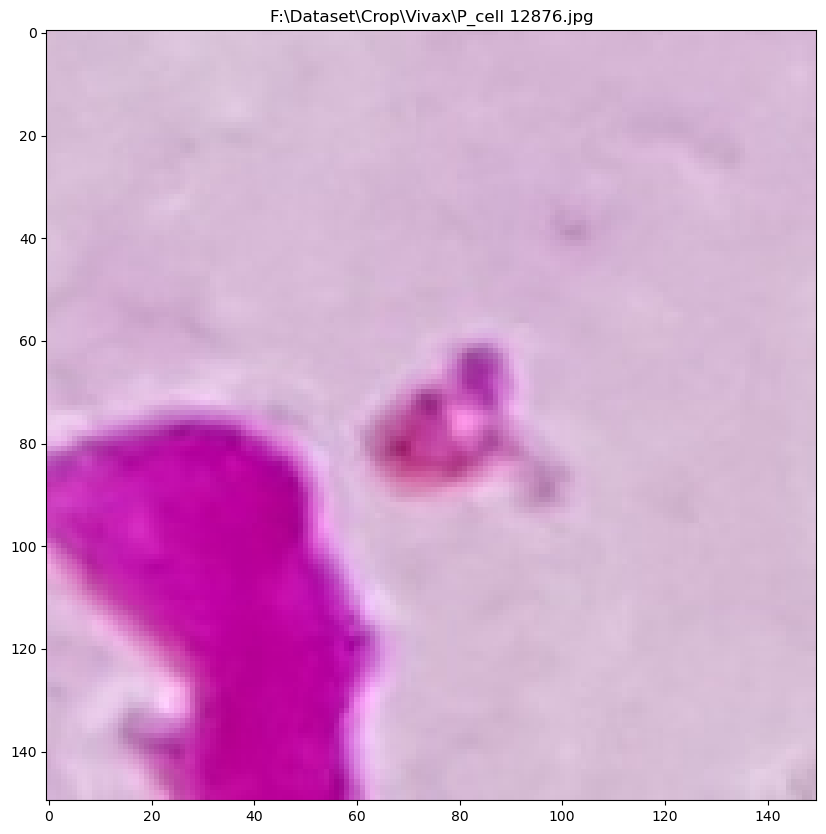

In [ ]:
mostrar(cv2.imread(vivax_names_train[r]),vivax_names_train[r]);

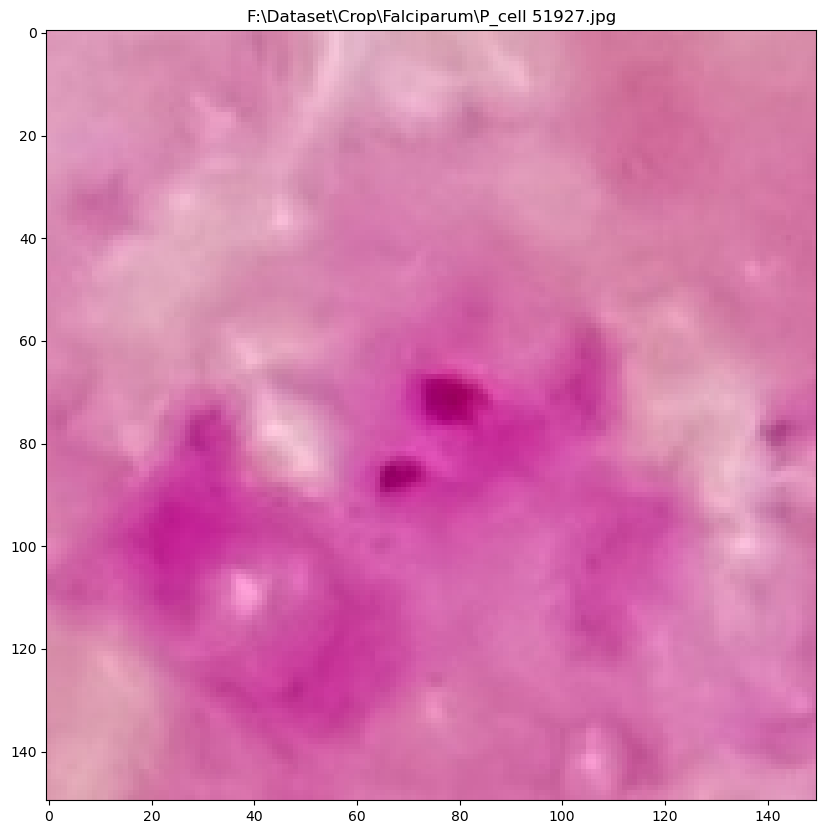

In [ ]:
mostrar(cv2.imread(falciparum_names_train[r]),falciparum_names_train[r]);

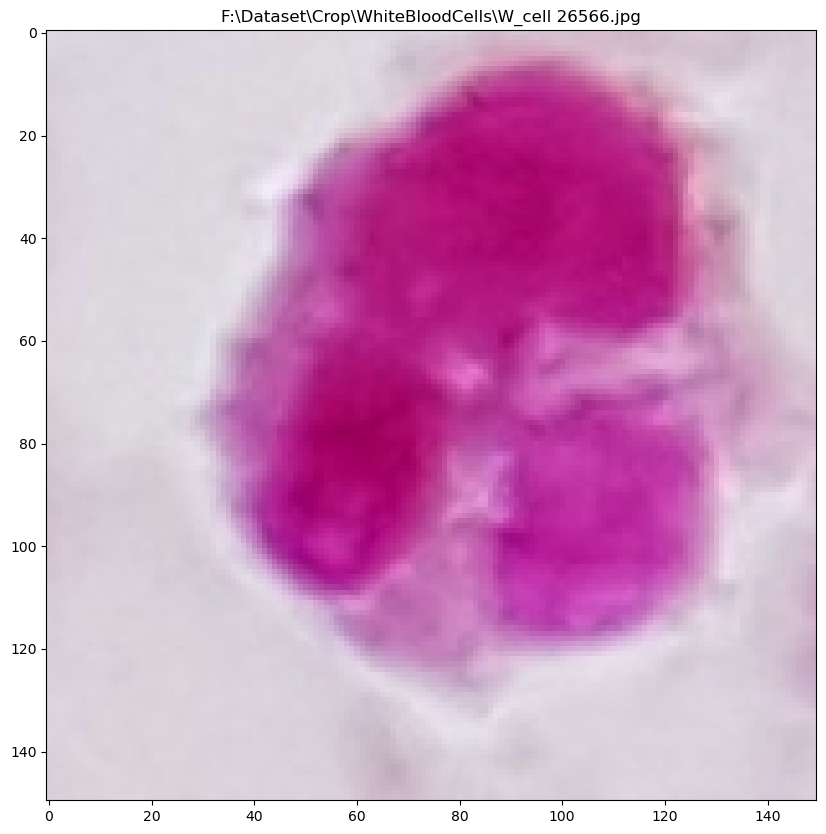

In [ ]:
mostrar(cv2.imread(white_names_train[r]),white_names_train[r]);

## Data

In [ ]:
path_model = r'F:\Dataset\ModelCNN'

In [ ]:
image_size = 50

In [ ]:
arquivo1= path_model + "\Cells.npy"
arquivo1

'F:\\Dataset\\ModelCNN\\Cells.npy'

In [ ]:
if os.path.exists(arquivo1):
  print(f"O arquivo {arquivo1} Está na pasta.")
  cells = np.load(path_model + "\Cells.npy")
  labels = np.load(path_model + "\Labels.npy")
  # cells = arquivo1 #Conjunto das imagens
  # labels = arquivo2 #Labels
else:
  print(f"O arquivo {arquivo1} Não está existe.")
################################################################################
  np.random.seed(123)
  data = []
  labels = []
  #print(data,labels)
  image_size = 50
  qtd=0
  inicio = time.time()
  # Separa as imagens, a adiciona mais rodando as imagens.

  print('Vivax')
  for i in vivax_names_train:
      try:

          image = cv2.imread(i)
          image_array = Image.fromarray(image , 'RGB')
          resize_img = image_array.resize((image_size , image_size))
          #rotated45 = resize_img.rotate(45) #Rotaciona
          #rotated75 = resize_img.rotate(75) #Rotaciona
          #blur = cv2.blur(np.array(resize_img) ,(10,10))
          data.append(np.array(resize_img))
          #data.append(np.array(rotated45))
          #data.append(np.array(rotated75))
          #data.append(np.array(blur))
          labels.append(1)
          #labels.append(1)
          #labels.append(1)
          #labels.append(1)
          qtd+=1
          if qtd==(tamanho//2):
            print("Metade")

      except AttributeError:
          print('error')
  qtd=0
  print('Falciparum')
  for u in falciparum_names_train:
      try:

          image = cv2.imread(u)
          image_array = Image.fromarray(image , 'RGB')
          resize_img = image_array.resize((image_size , image_size))
          #rotated45 = resize_img.rotate(45) #Rotaciona
          #rotated75 = resize_img.rotate(75) #Rotaciona
          data.append(np.array(resize_img))
          #data.append(np.array(rotated45))
          #data.append(np.array(rotated75))
          labels.append(2)
          #labels.append(0)
          #labels.append(0)
          qtd+=1
          if qtd==(tamanho//2):
            print("Metade")

      except AttributeError:
          print('error')
  qtd=0
  print('White')
  for o in white_names_train:
      try:

          image = cv2.imread(o)
          image_array = Image.fromarray(image , 'RGB')
          resize_img = image_array.resize((image_size , image_size))
          #rotated45 = resize_img.rotate(45) #Rotaciona
          #rotated75 = resize_img.rotate(75) #Rotaciona
          data.append(np.array(resize_img))
          #data.append(np.array(rotated45))
          #data.append(np.array(rotated75))
          labels.append(0)
          #labels.append(0)
          #labels.append(0)
          qtd+=1
          if qtd==(tamanho//2):
            print("Metade")

      except AttributeError:
          print('error')
  fim_treino = time.time()
  minutos_1 = round((fim_treino - inicio) / 60, 2)
  print(f'Tempo de treinamento: {minutos_1} minutos' )
  #############################################################################
  inicio = time.time()
  cells = np.array(data) #Conjunto das imagens
  labels = np.array(labels) #Labels

  np.save(path_model+'\Cells' , cells)
  np.save(path_model+'\Labels' , labels)
  fim_treino = time.time()
  minutos_2 = round((fim_treino - inicio) / 60, 2)
  print('Tempo de treinamento: ', minutos_2)

O arquivo F:\Dataset\ModelCNN\Cells.npy Está na pasta.


In [ ]:
type(labels)

numpy.ndarray

In [ ]:
print(f'Cells : {cells.shape} | labels : {labels.shape}')

Cells : (30000, 50, 50, 3) | labels : (30000,)


In [ ]:
qtd=6 #Quantidade de imagens para plot

## Plotagem 1

In [ ]:
cells.shape[0]

30000

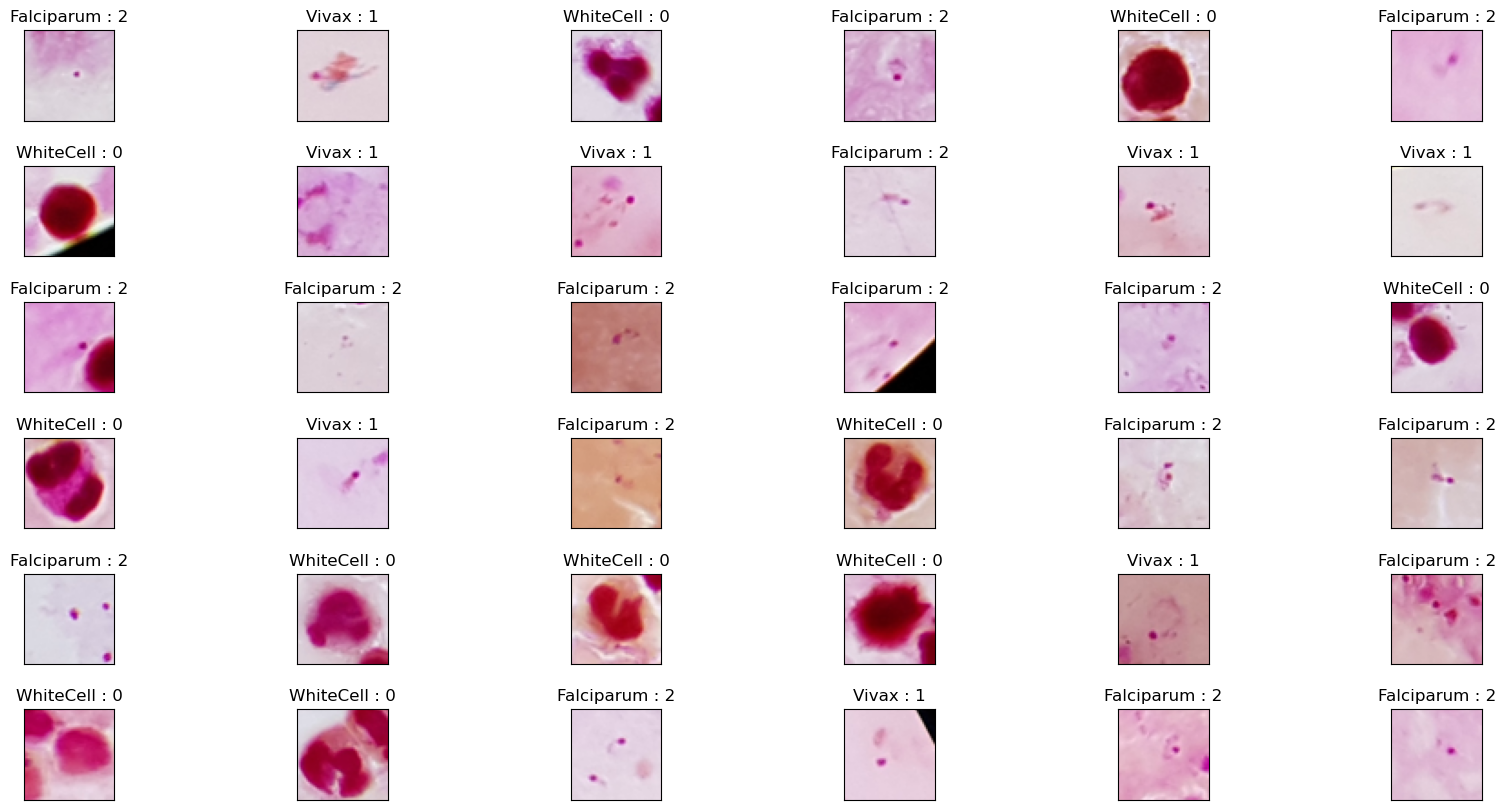

In [ ]:
plt.figure(1 , figsize = (20 , 10))
n = 0
for i in range(qtd*qtd):
    n += 1
    r = np.random.randint(0 , cells.shape[0] , 3)
    plt.subplot(qtd , qtd , n)
    plt.subplots_adjust(hspace = 0.5 , wspace = 0.5)
    plt.imshow(cells[r[0]])
    if labels[r[0]] == 1:
      label_text = 'Vivax'
    elif labels[r[0]] == 2:
      label_text = 'Falciparum'
    else:
      label_text = 'WhiteCell'
    plt.title(f"{label_text} : {labels[r[0]]}")  # Use f-string for formatted title
    #plt.title('{} : {}'.format('Infected' if labels[r[0]] == 1 else 'Unifected' , labels[r[0]]) )
    plt.xticks([]) , plt.yticks([])

plt.show()

## Plotagem 2

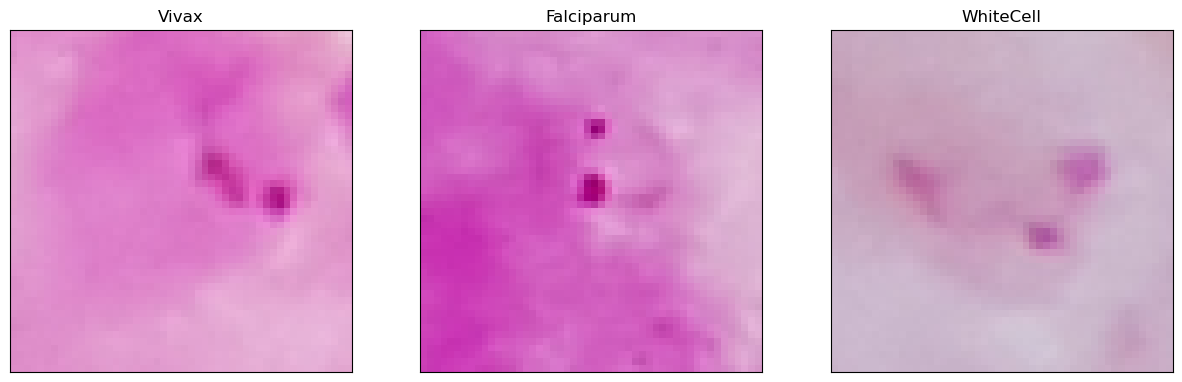

In [ ]:
plt.figure(1, figsize = (15 , 7))
plt.subplot(1 , 3 , 1)
plt.imshow(cells[(tamanho-1)])
plt.title('Vivax')
plt.xticks([]) , plt.yticks([])

plt.subplot(1 , 3 , 2)
plt.imshow(cells[int(tamanho*1.5)])
plt.title('Falciparum')
plt.xticks([]) , plt.yticks([])

plt.subplot(1 , 3 , 3)
plt.imshow(cells[(int(tamanho*2.5))])#5000
plt.title('WhiteCell')
plt.xticks([]) , plt.yticks([])

plt.show()

## Formatação de Imagens

In [ ]:
# formata as imagens para um novo formato


In [ ]:
if os.path.exists(arquivo):
  print(f"O arquivo {arquivo} Está na pasta.")
  cells = np.load(path_model + "\Cells.npy")
  labels = np.load(path_model + "\Labels.npy")
else:
  print(f"O arquivo {arquivo} Não está na pasta.")
  n = np.arange(cells.shape[0])
  #print(n)
  np.random.shuffle(n)
  inicio = time.time()
  cells = cells[n]
  labels = labels[n]
  cells = cells.astype(np.float32)
  labels = labels.astype(np.int32)
  cells = cells/255
  fim_treino = time.time()
  minutos_3 = round((fim_treino - inicio) / 60, 2)
  print('Tempo de treinamento: ', minutos_3)
  np.save(path_model+'\Cells' , cells)
  np.save(path_model+'\Labels' , labels)

O arquivo C:/Malaria/Tudo/dataset/test/images\TF112_CJ10\20170830_202539.jpg Está na pasta.


In [ ]:
# labels

## Adiciona mais Bibliotecas

In [ ]:
# Proximas bibliotecas a serem usadas.
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import (Conv2D,MaxPooling2D,Flatten,Dense,Dropout,)
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import keras

In [ ]:
print(tf.__version__)

2.10.1


## Separando dados para Teste e Treino

In [ ]:
inicio = time.time()
x_train , x , y_train , y = train_test_split(cells , labels , test_size = 0.2 , random_state = 43)
x_eval , x_test , y_eval , y_test = train_test_split(x , y , test_size = 0.5 , random_state = 43)
print(y_train)
y_train = to_categorical(y_train, num_classes=3) # num_classes=2
y_test = to_categorical(y_test, num_classes=3)
y_eval = to_categorical(y_eval, num_classes=3)
fim_treino = time.time()
minutos_4 = round((fim_treino - inicio) / 60, 2)
minutos_4 = max(minutos_4, 0)
print(f'Tempo de treinamento: {minutos_4}')

[2 2 0 ... 1 0 2]
Tempo de treinamento: 0.01


In [ ]:
print(f'train data shape {x_train.shape} ,eval data shape {x_eval.shape} , test data shape {x_test.shape}')

train data shape (24000, 50, 50, 3) ,eval data shape (3000, 50, 50, 3) , test data shape (3000, 50, 50, 3)


In [ ]:
#print(y_train)

## Definição do modelo CNN

In [ ]:
# Definindo o modelo da CNN
model = tf.keras.Sequential()
model.add(Conv2D(128, kernel_size=(7, 7), activation="relu", input_shape=(image_size , image_size ,3)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(32, kernel_size=(3, 3), activation="relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(128, activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(3, activation="softmax"))

## Treino

In [ ]:
# !nvidia-smi

In [ ]:
path_model = r'F:\Dataset\ModelCNN'

In [ ]:
arquivo_model= 'ModelCNN.h5'

In [ ]:
# Compilando o modelo

# Caminho do arquivo que você deseja verificar
arquivo = f"{path_model}\\{arquivo_model}"

# Verifica se o arquivo existe
if os.path.exists(arquivo):
  print(f"O arquivo {arquivo} existe.")
  model= keras.models.load_model(f"{path_model}/{arquivo_model}")
else:
  print(f"O arquivo {arquivo} não existe.")
  #Define the optimizer with the desired learning rate
  optimizer = Adam(learning_rate=0.001)  # Adjust the learning rate as needed

  # Early stopping callback
  early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

  #model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

  # Compile the model specifying the optimizer
  model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
  inicio = time.time()

  # Treinamento do modelo
  model.fit(x_train, y_train, epochs=50, batch_size=100, validation_split=0.2,  callbacks=[early_stopping])
  fim_treino = time.time()
  minutos_4 = round((fim_treino - inicio) / 60, 2)
  print('Tempo de treinamento: ', minutos_4)
  arquivo_model= 'ModelCNN.h5'
  model.save(f"{path_model}/ModelCNN.h5")

O arquivo F:\Dataset\ModelCNN\ModelCNN.h5 existe.


## Avaliação do Modelo

In [ ]:
# Avaliando o Modelo:
loss, acc = model.evaluate(x_test, y_test, verbose = 0);

print(f'Acurácia (%):  {(acc*100):.2f}')
print(f"Loss: {loss:.2f}")

Acurácia (%):  96.63
Loss: 0.12


In [ ]:
# # Avaliando o Modelo:
# # Usando os dados de avaliação (x_eval e y_eval)

# loss, acc = model.evaluate(x_eval, y_eval, verbose = 0);

# print(f'Acurácia no validador (%): {(acc*100):.2f}')
# print(f"Loss no validador: {loss:.2f}")

## Matriz de Confusão

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
class_names=['WhiteCell', 'Vivax', 'Falciparum']
# Faz predições no conjunto de teste
y_pred = model.predict(x_test)
y_pred_class = np.argmax(y_pred, axis=1)

# Converte rótulos para classes binárias
y_test_prob = np.argmax(y_test, axis=1)

# Calcula a matriz de confusão
conf_matrix = confusion_matrix(y_test_prob, y_pred_class)

94/94 [==============================] - 1s 6ms/step


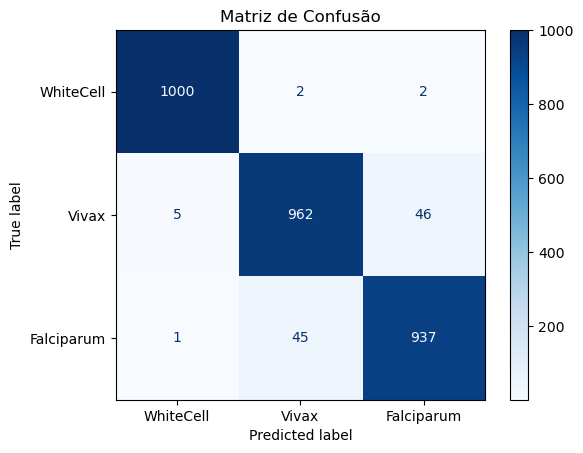

In [ ]:
# Plotar a matriz de confusão
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusão')
plt.show()

## Precisão

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

In [ ]:
# Calculate precision, recall, F1-score, and support
precision, recall, fscore, support = precision_recall_fscore_support(y_test_prob, y_pred_class, average=None)

# Print metrics for each class
for i, class_name in enumerate(class_names):
    print(f'Precisão ({class_name}): {(precision[i]*100):.2f}')
    print(f'Recall ({class_name}): {(recall[i]*100):.2f}')
    print(f'F1-score ({class_name}): {(fscore[i]*100):.2f}\n')

# Print macro-averaged metrics
print(f'Precisão média: {(precision.mean()*100):.2f}')  # Macro-averaged precision
print(f'Recall médio: {(recall.mean()*100):.2f}')  # Macro-averaged recall
print(f'F1-score médio: {(fscore.mean()*100):.2f}')  # Macro-averaged F1-score


Precisão (WhiteCell): 99.40
Recall (WhiteCell): 99.60
F1-score (WhiteCell): 99.50

Precisão (Vivax): 95.34
Recall (Vivax): 94.97
F1-score (Vivax): 95.15

Precisão (Falciparum): 95.13
Recall (Falciparum): 95.32
F1-score (Falciparum): 95.22

Precisão média: 96.62
Recall médio: 96.63
F1-score médio: 96.63


## Visualização da Previsão

In [ ]:
#import numpy as np
from random import randint

94/94 [==============================] - 0s 5ms/step


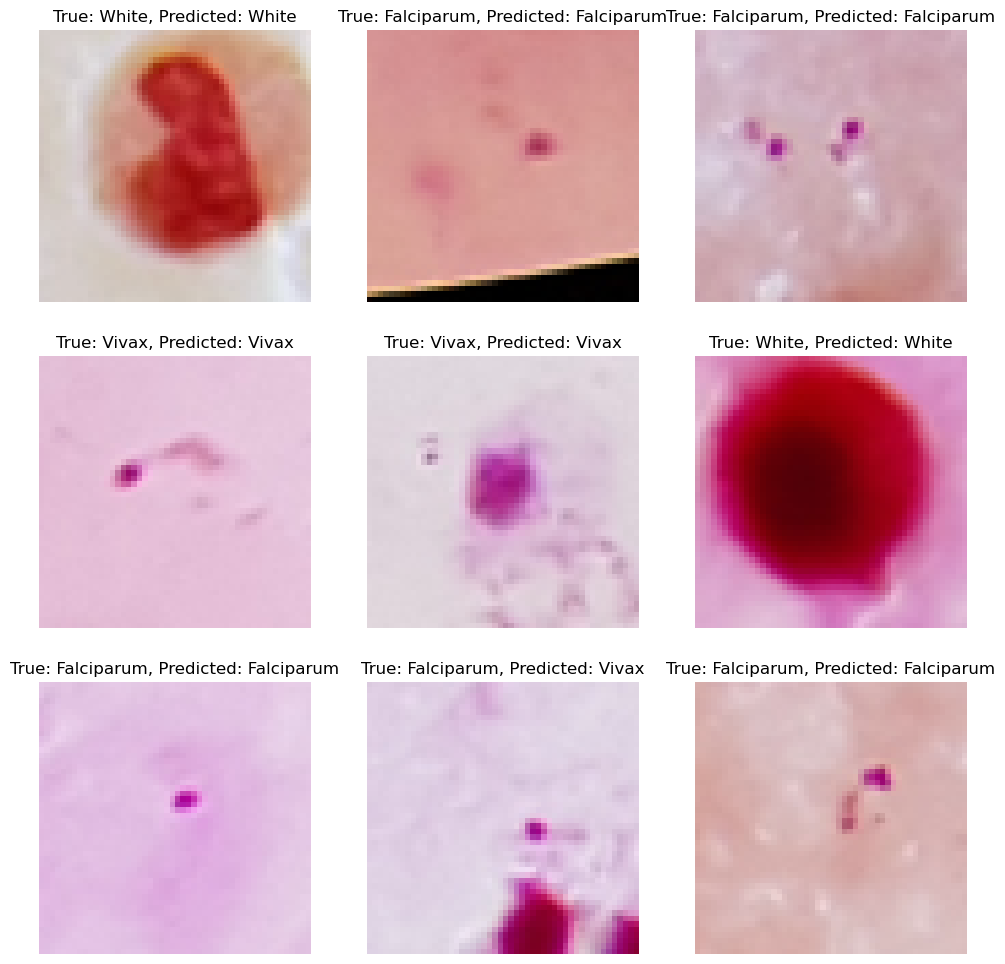

In [ ]:
# Faz previsões no conjunto de teste
predictions = model.predict(x_test)

# Converter as previsões em classes
predicted_classes = np.argmax(predictions, axis=1)

# Visualizar algumas imagens de teste com suas previsões
num_rows = 3
num_cols = 3
plt.figure(figsize=(12, 12))

for i in range(num_rows * num_cols):
    index = randint(0, len(x_test) - 1)
    img = x_test[index]
    true_label = y_test_prob[index]
    predicted_label = predicted_classes[index]

    if true_label==1:
      true_label="Vivax"
    elif true_label==2:
      true_label="Falciparum"
    else:
      true_label="White"

    if predicted_label==1:
      predicted_label="Vivax"
    elif predicted_label==2:
      predicted_label="Falciparum"
    else:
      predicted_label="White"

    plt.subplot(num_rows, num_cols, i + 1)
    plt.imshow(img)
    plt.title(f'True: {true_label}, Predicted: {predicted_label}')
    plt.axis('off')

plt.show()


# Imagens do Yolo

In [ ]:
len (images_yolo)
yolo_tensor = tf.convert_to_tensor(images_yolo)
yolo_array = np.array(images_yolo)

In [ ]:
predicoes = model.predict(yolo_tensor)
vivax=0
falc =0
white=0
# Interpretar os resultados
for i, pred in enumerate(predicoes):
  # Obter a categoria com maior probabilidade
  categoria_predita = tf.argmax(pred).numpy()

  if categoria_predita==1:
    texto='vivax'
    vivax+=1
  elif categoria_predita==2:
    texto='Falciparum'
    falc+=1
  else:
    texto='White'
    white+=1

  for n in range(3):
    if pred[n] >= 0.50:  # Definir valor de limiar (ex: 0.95)
      #print(pred[n])
      if n == 1:
        texto2 = 'Vivax'
      elif n == 2:
        texto2 = 'Falciparum'
      else:
        texto2 = 'White'

  print(f"Imagem {i}: Categoria predita - {texto}, Probabilidades - {texto2}")

  # if i>=80 and i<=83:
  #   mostrar(yolo_tensor[i], texto)
  # Exibir a classificação e as probabilidades
print(f'Quantidade de Vivax: {vivax} | Falciparum: {falc} | White: {white} | Qtd total: {len (yolo_tensor)}')

1/1 [==============================] - 0s 288ms/step
Imagem 0: Categoria predita - White, Probabilidades - White
Imagem 1: Categoria predita - White, Probabilidades - White
Imagem 2: Categoria predita - White, Probabilidades - White
Imagem 3: Categoria predita - White, Probabilidades - White
Imagem 4: Categoria predita - White, Probabilidades - White
Imagem 5: Categoria predita - White, Probabilidades - White
Imagem 6: Categoria predita - White, Probabilidades - White
Imagem 7: Categoria predita - White, Probabilidades - White
Imagem 8: Categoria predita - White, Probabilidades - White
Imagem 9: Categoria predita - White, Probabilidades - White
Imagem 10: Categoria predita - White, Probabilidades - White
Imagem 11: Categoria predita - White, Probabilidades - White
Imagem 12: Categoria predita - White, Probabilidades - White
Imagem 13: Categoria predita - White, Probabilidades - White
Imagem 14: Categoria predita - White, Probabilidades - White
Imagem 15: Categoria predita - White, Prob

In [ ]:
# if minutos_2<0:
#   minutos_2=0
# if minutos_3<0:
#   minutos_3=0
# print(f'Tempo 1:{minutos_1} | Tempo 2: {minutos_2} | Tempo 3: {minutos_3} | Tempo 4: {minutos_4} Tempo Total: {minutos_1+minutos_2+minutos_3+minutos_4}')

Tempo 1:20.26 | Tempo 2: 0 | Tempo 3: 0 | Tempo 4: 2.63 Tempo Total: 22.89


In [ ]:
#model1= keras.models.load_model(f"{path_model}/ModelCNN.h5")

In [ ]:
#  cells = None
#  data = None